# This needs to be your file path!!

In [33]:
import sys, os

ELI_lamp_path = "/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024/"

# From here, nothing should change

In [34]:
ROOT_FOLDER = os.path.dirname(ELI_lamp_path) # point this to the folder containing LAMP
print(ROOT_FOLDER)
sys.path.append(ROOT_FOLDER)
from LAMP import Experiment
# ----------------------------------
import matplotlib.pyplot as plt 
import numpy as np
from scipy.signal import savgol_filter

ex = Experiment(ROOT_FOLDER)
ESpec_low = ex.get_diagnostic('ESpec_low')

/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024
Using DAQ: GeminiMirage
Adding Diagnostic: ESpec_low [ESpec]


In [35]:
if ex.DAQ.config is None:
    ex.DAQ.config = {}
ex.DAQ.config.setdefault("shotnum_zfill", 0)
print("DAQ config (patched):", ex.DAQ.config)

DAQ config (patched): {'shotnum_zfill': 0}


In [36]:
# /Users/cmcanespie/Documents/Gemini_cells_2024/Mirage/HighEspec/20240306/run05
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec_low', timeline)
shot_dicts

[{'date': 20240304, 'run': 'run11', 'shotnum': 1},
 {'date': 20240304, 'run': 'run11', 'shotnum': 2},
 {'date': 20240304, 'run': 'run11', 'shotnum': 3},
 {'date': 20240304, 'run': 'run11', 'shotnum': 4},
 {'date': 20240304, 'run': 'run11', 'shotnum': 5},
 {'date': 20240304, 'run': 'run11', 'shotnum': 6},
 {'date': 20240304, 'run': 'run11', 'shotnum': 7},
 {'date': 20240304, 'run': 'run11', 'shotnum': 8},
 {'date': 20240304, 'run': 'run11', 'shotnum': 9},
 {'date': 20240304, 'run': 'run11', 'shotnum': 10},
 {'date': 20240304, 'run': 'run11', 'shotnum': 11},
 {'date': 20240304, 'run': 'run11', 'shotnum': 12},
 {'date': 20240304, 'run': 'run11', 'shotnum': 13},
 {'date': 20240304, 'run': 'run11', 'shotnum': 14}]

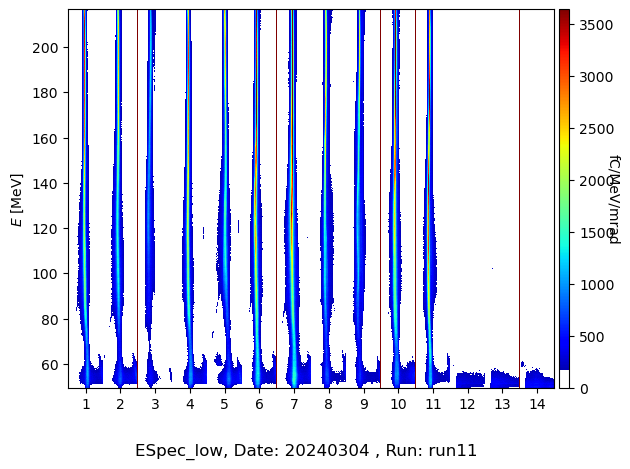

In [37]:
ESpec_low.montage(timeline, vmin=0)
plt.tight_layout()

# Plot an individual shot

for checking things

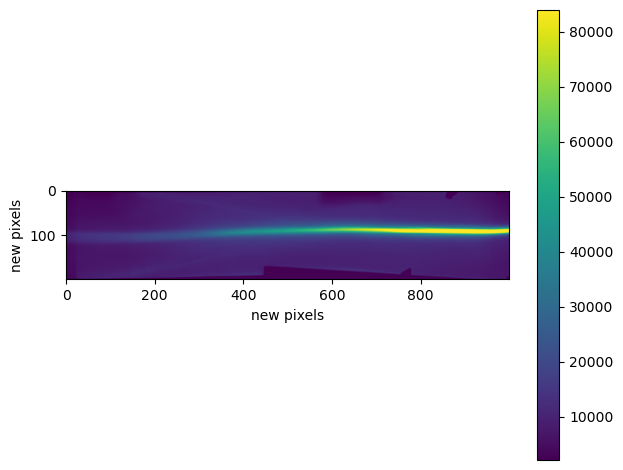

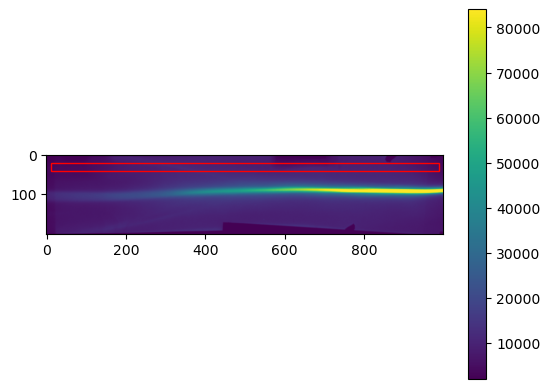

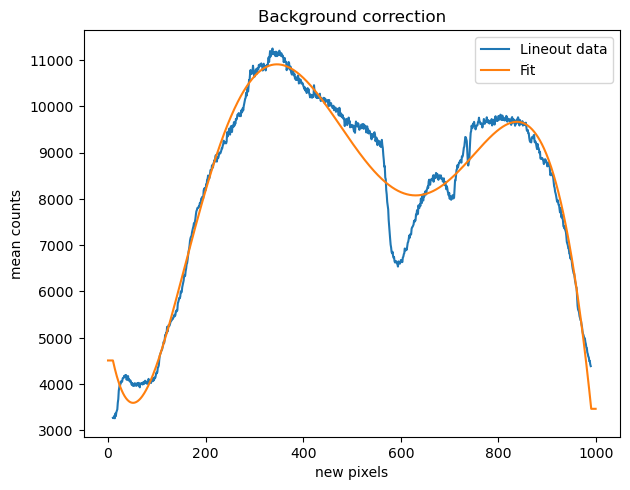

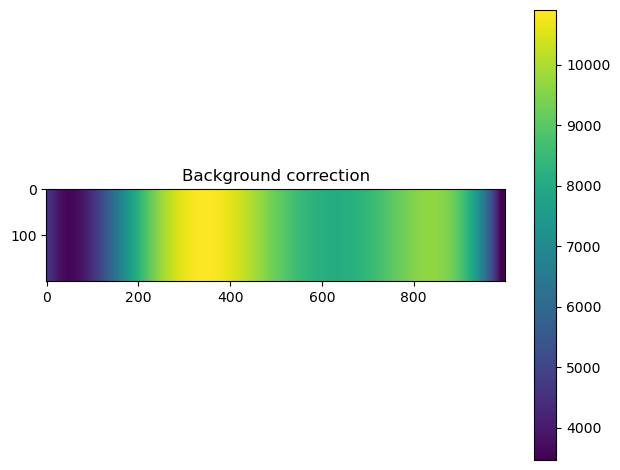

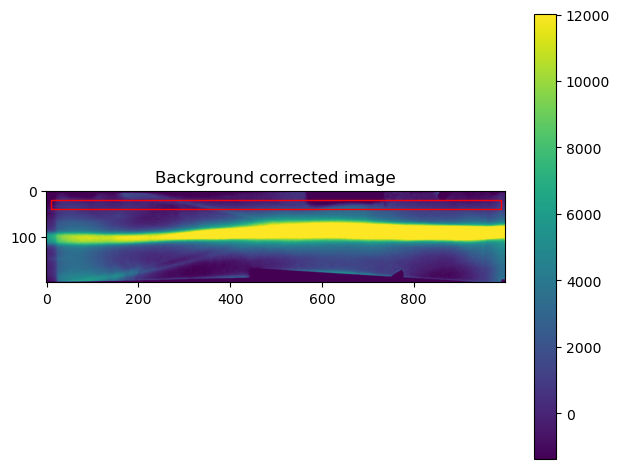

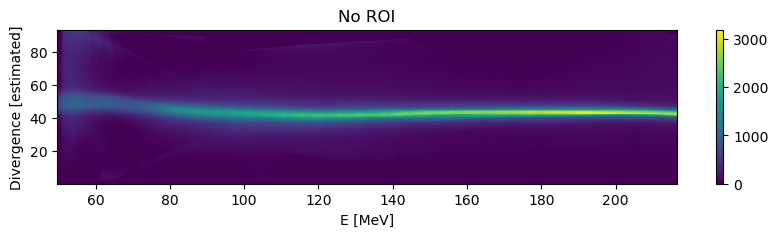

In [38]:
# timeline = {'date': 20240304, 'run': 'run11'}
eg_shot = {'date': '20240304', 'run': 'run11', 'shotnum': 4}
img, x, y = ESpec_low.get_proc_shot(eg_shot, debug=True)

plt.figure(figsize=(10,2))
plt.title('No ROI')
plt.pcolormesh(x, y, img, vmin=0)
plt.xlabel('E [MeV]')
plt.ylabel('Divergence [estimated]')
plt.colorbar()

# Spectra with and without the ROI

(49.66579993762577, 224.70165687070096)

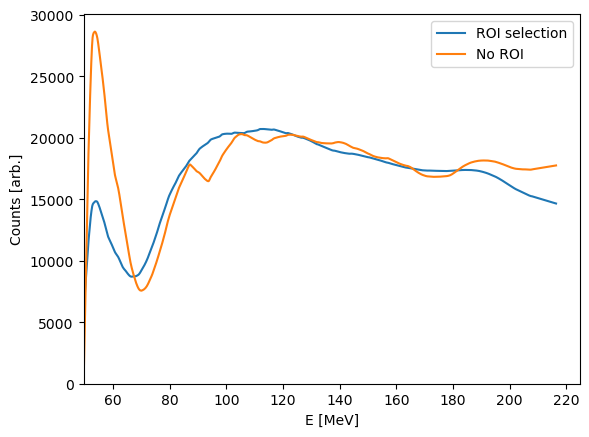

In [39]:
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec_low', timeline)

eg_shot = {'date': 20240304, 'run': 'run11', 'shotnum': 4}
spec, MeV = ESpec_low.get_spectrum(eg_shot, roi_mrad=[25,55])
spec = savgol_filter(spec, window_length=51, polyorder=1) # Smooth out the spectra if it has bumps in it
plt.plot(MeV, spec, label='ROI selection')

eg_shot = {'date': 20240304, 'run': 'run11', 'shotnum': 4}
spec, MeV = ESpec_low.get_spectrum(eg_shot)
spec = savgol_filter(spec, window_length=51, polyorder=1) # Smooth out the spectra if it has bumps in it
plt.plot(MeV, spec, label='No ROI')

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV))

# Plot overplotted spectra

For when nothing is changed in a run

(49.66579993762577, 224.70165687070096)

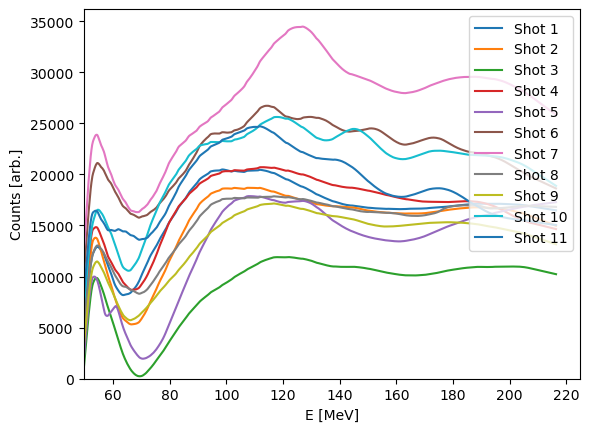

In [40]:
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec_low', timeline)

for n,i in enumerate(shot_dicts[:-3]):
    spec, MeV = ESpec_low.get_spectrum(i, roi_mrad=[25,55])
    spec = savgol_filter(spec, window_length=51, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot '+str(n+1))

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV))

(0.471105492785743, 97.63669243061015)

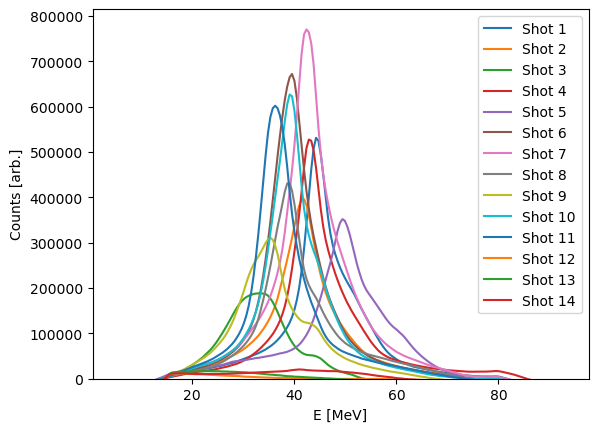

In [31]:
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec_low', timeline)

for n,i in enumerate(shot_dicts):
    spec, MeV = ESpec_low.get_div(i)
    # spec = savgol_filter(spec, window_length=51, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot '+str(n+1))

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV))